## Data source
* https://borealisdata.ca/file.xhtml?fileId=710108&version=1.0
```
MULTI-WAVELENGTH FLUOROMETER
       An in-situ probe connected to a spectrometer was used for in-line
       monitoring of culture fluorescence under excitation of two LED light
       sources at 365 nm (λ_ex=365 nm) and 410 nm (λ_ex=410 nm) (Karakach et
       al., 2019). The spectrometer captured emission spectra from 300 to 1000
       nm from each excitation light every 5 minutes.
```


In [1]:
import pandas as pd

In [51]:
with open("mvda_adenovirus_bioprocess_data/AdV01_MWF/spectra/AdV01_00000.dat","r") as f:
    data = f.read()

for l in data.split("\n"):
    print(l)

Process_Name: Br02-AD-F hycell
Date: 14/05/2022
Time: 10:35:53
Process_Time(days): 0.0002116
Light_Status(1=on): 1 1 
Light_Name: uv 365 uv 400
Light_Control_Type(0=Phidget,1=COMport,2=LPT1,3=LabJack,4=LabJack(reversed),5=Phidget(reversed)): 0 0
Voltage(V): 5.5 5.5
Integration_Time(ms): 300.0 300.0
Scans_To_Average: 10 10
Boxcar_Width(px): 20
Acquisition_Interval(min): 5.0
--------------------------------------------------
180.96483 1.6383749999995416 13.926187499999742
181.18397226108897 1.6383749999995416 13.926187499999742
181.40310466223272 1.6383749999995416 13.926187499999742
181.62222720024678 5.324718750000102 -11.468624999999975
181.84133987194656 -34.201078125000095 -3.4815468749998217
182.06044267414745 -27.033187500000622 36.45384375000003
182.27953560366498 14.13098437499957 -16.79334374999962
182.49861865731452 -72.90768750000007 -49.560843749999094
182.71769183191154 -18.226921875000244 -24.57562499999949
182.93675512427143 -0.8191875000006803 11.46862499999952
183.15580

<Axes: xlabel='Col1'>

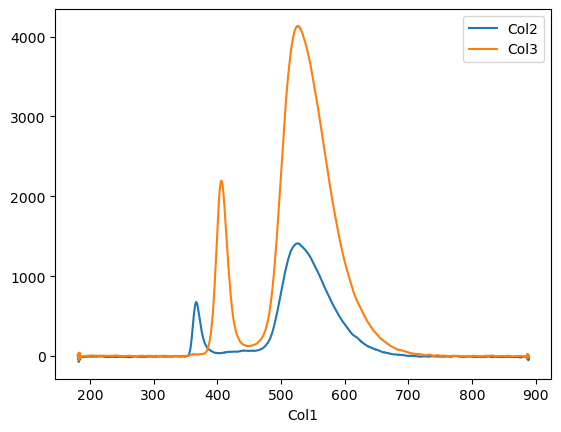

In [55]:
meta_text, data_text = data.split('--------------------------------------------------')

from io import StringIO
df_data = pd.read_csv(StringIO(data_text.strip()), sep=r'\s+', header=None)

# Assign generic column names
df_data.columns = ['Col1', 'Col2', 'Col3']
df_data.plot(x='Col1',y=['Col2','Col3'])